# Notebook 03 — Modelado

**Proyecto:** Predicción de Riesgo de Incumplimiento Crediticio  
**Inputs:** `data/processed/data_smote.csv` · `data/processed/data_test.csv`  
**Outputs:** `models/*.pkl` · `models/resultados_comparacion.csv`

Entrenamos cuatro modelos de clasificación, los comparamos con métricas orientadas al negocio (Recall y AUC-ROC como prioridad) y exportamos el modelo ganador.

---

## Índice
1. Carga de librerías y datos
2. Baseline — Regresión Logística
3. Árbol de Decisión
4. Random Forest
5. XGBoost
6. Comparación de modelos
7. Ajuste de umbral de clasificación
8. Exportar modelo ganador

---
## 1. Carga de librerías y datos

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import os
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, f1_score,
    recall_score, precision_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED   = 42
TARGET = 'SeriousDlqin2yrs'

# Carga de datos procesados
train = pd.read_csv('../data/processed/data_smote.csv')
test  = pd.read_csv('../data/processed/data_test.csv')

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]
X_test  = test.drop(columns=[TARGET])
y_test  = test[TARGET]

os.makedirs('../models', exist_ok=True)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Features: {X_train.columns.tolist()}')

Train: (223958, 9)  |  Test: (30000, 9)
Features: ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome', 'DebtRatio', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']


---

### Función auxiliar de evaluación

Definimos una función reutilizable que calcula todas las métricas relevantes y genera la matriz de confusión y la curva ROC para cualquier modelo.

In [30]:
def evaluar_modelo(nombre, modelo, X_test, y_test, umbral=0.5):
    """
    Evalúa un modelo entrenado sobre el test set.
    Retorna un dict con las métricas principales.
    """
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= umbral).astype(int)

    auc     = roc_auc_score(y_test, y_prob)
    recall  = recall_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred)
    acc     = (y_pred == y_test).mean()

    print(f'\n{'='*50}')
    print(f'  {nombre}')
    print(f'{'='*50}')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  Recall    : {recall:.4f}  ← prioridad')
    print(f'  Precisión : {prec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  Accuracy  : {acc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['No moroso', 'Moroso']))

    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No moroso', 'Moroso'],
                yticklabels=['No moroso', 'Moroso'])
    axes[0].set_title(f'{nombre} — Matriz de confusión')
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicho')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color='#4A90D9', lw=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
    axes[1].set_title(f'{nombre} — Curva ROC')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        'Modelo': nombre, 'AUC-ROC': round(auc, 4),
        'Recall': round(recall, 4), 'Precisión': round(prec, 4),
        'F1-Score': round(f1, 4), 'Accuracy': round(acc, 4)
    }

resultados = []  # acumulamos métricas de todos los modelos
print('Función de evaluación lista.')

Función de evaluación lista.


---
## 2. Baseline — Regresión Logística

El modelo más simple e interpretable. Nos sirve como referencia mínima: si un modelo más complejo no le gana claramente, no vale la pena su complejidad adicional.

In [32]:
logreg = LogisticRegression(
    max_iter    = 1000,
    class_weight= 'balanced',
    random_state= SEED,
    solver      = 'lbfgs'
)
logreg.fit(X_train, y_train)

joblib.dump(logreg, '../models/logreg.pkl')
print('Regresión Logística entrenada y exportada.')

Regresión Logística entrenada y exportada.



  Regresión Logística
  AUC-ROC   : 0.8055
  Recall    : 0.5781  ← prioridad
  Precisión : 0.2631
  F1-Score  : 0.3616
  Accuracy  : 0.8636

              precision    recall  f1-score   support

   No moroso       0.97      0.88      0.92     27995
      Moroso       0.26      0.58      0.36      2005

    accuracy                           0.86     30000
   macro avg       0.61      0.73      0.64     30000
weighted avg       0.92      0.86      0.89     30000



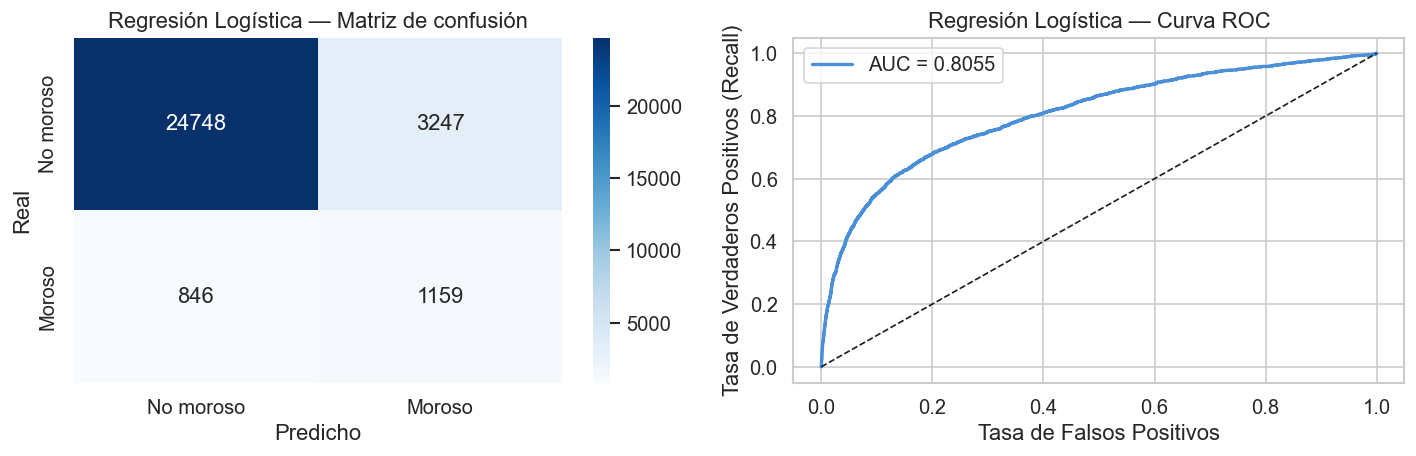

In [33]:
res_lr = evaluar_modelo('Regresión Logística', logreg, X_test, y_test)
resultados.append(res_lr)

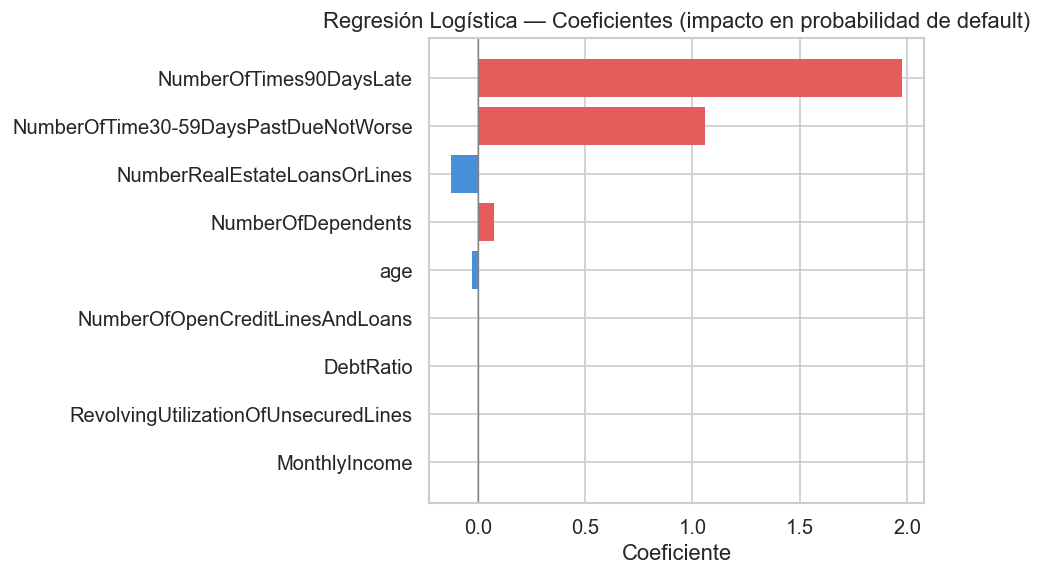

In [34]:
# Coeficientes — interpretabilidad del modelo
coefs = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coeficiente': logreg.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colores = ['#E55C5C' if c > 0 else '#4A90D9' for c in coefs['Coeficiente']]
ax.barh(coefs['Feature'], coefs['Coeficiente'], color=colores, edgecolor='none')
ax.axvline(0, color='gray', lw=0.8)
ax.set_title('Regresión Logística — Coeficientes (impacto en probabilidad de default)')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

---
## 3. Árbol de Decisión

Permite extraer **reglas de negocio** legibles. Limitamos la profundidad para evitar sobreajuste y que el árbol sea interpretable.

In [35]:
dt = DecisionTreeClassifier(
    max_depth    = 6,       
    min_samples_leaf = 50,  
    class_weight = 'balanced',
    random_state = SEED
)
dt.fit(X_train, y_train)

joblib.dump(dt, '../models/decision_tree.pkl')
print('Árbol de Decisión entrenado y exportado.')

Árbol de Decisión entrenado y exportado.



  Árbol de Decisión
  AUC-ROC   : 0.8300
  Recall    : 0.3776  ← prioridad
  Precisión : 0.3904
  F1-Score  : 0.3839
  Accuracy  : 0.9190

              precision    recall  f1-score   support

   No moroso       0.96      0.96      0.96     27995
      Moroso       0.39      0.38      0.38      2005

    accuracy                           0.92     30000
   macro avg       0.67      0.67      0.67     30000
weighted avg       0.92      0.92      0.92     30000



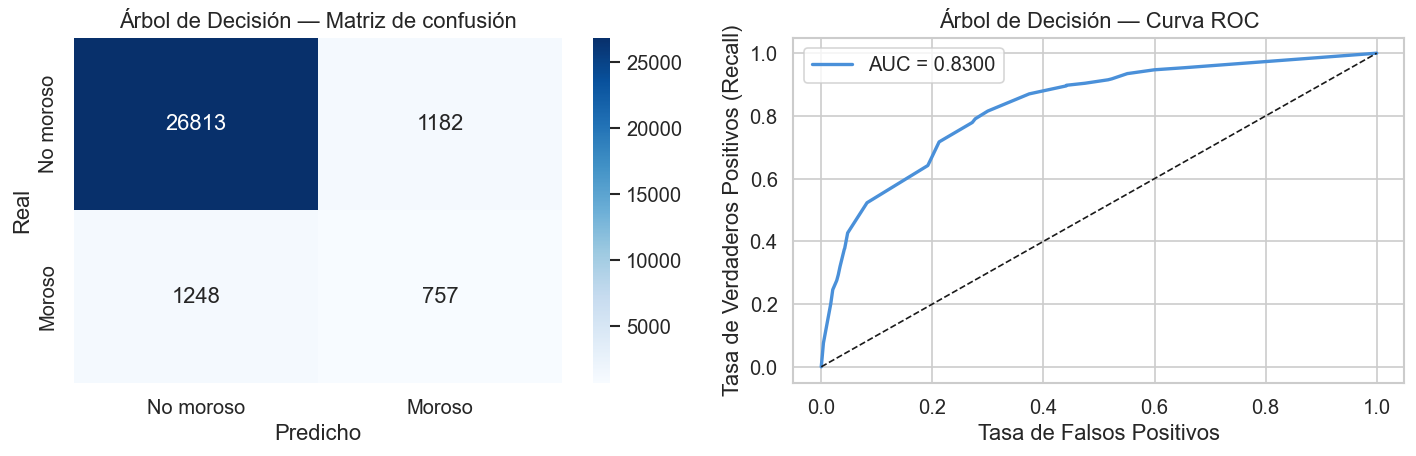

In [36]:
res_dt = evaluar_modelo('Árbol de Decisión', dt, X_test, y_test)
resultados.append(res_dt)

In [37]:
# Reglas de negocio — primeros 3 niveles del árbol
print('=== Reglas del árbol (primeros 3 niveles) ===')
print(export_text(dt, feature_names=list(X_train.columns), max_depth=3))

=== Reglas del árbol (primeros 3 niveles) ===
|--- NumberOfTime30-59DaysPastDueNotWorse <= 0.00
|   |--- NumberOfTimes90DaysLate <= 0.00
|   |   |--- RevolvingUtilizationOfUnsecuredLines <= 0.32
|   |   |   |--- RevolvingUtilizationOfUnsecuredLines <= 0.12
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- RevolvingUtilizationOfUnsecuredLines >  0.12
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- RevolvingUtilizationOfUnsecuredLines >  0.32
|   |   |   |--- NumberOfOpenCreditLinesAndLoans <= 0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- NumberOfOpenCreditLinesAndLoans >  0.50
|   |   |   |   |--- truncated branch of depth 3
|   |--- NumberOfTimes90DaysLate >  0.00
|   |   |--- NumberOfTimes90DaysLate <= 1.00
|   |   |   |--- class: 1
|   |   |--- NumberOfTimes90DaysLate >  1.00
|   |   |   |--- NumberOfTimes90DaysLate <= 1.00
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- NumberOfTimes90DaysLate >  1.00
|   |   |

---
## 4. Random Forest

Ensemble de árboles que reduce la varianza del árbol individual. Más robusto ante outliers y variables ruidosas.

In [38]:
rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 10,
    min_samples_leaf = 20,
    class_weight = 'balanced',
    random_state = SEED,
    n_jobs       = -1  
)
rf.fit(X_train, y_train)

joblib.dump(rf, '../models/random_forest.pkl')
print('Random Forest entrenado y exportado.')

Random Forest entrenado y exportado.



  Random Forest
  AUC-ROC   : 0.8513
  Recall    : 0.4454  ← prioridad
  Precisión : 0.3770
  F1-Score  : 0.4083
  Accuracy  : 0.9137

              precision    recall  f1-score   support

   No moroso       0.96      0.95      0.95     27995
      Moroso       0.38      0.45      0.41      2005

    accuracy                           0.91     30000
   macro avg       0.67      0.70      0.68     30000
weighted avg       0.92      0.91      0.92     30000



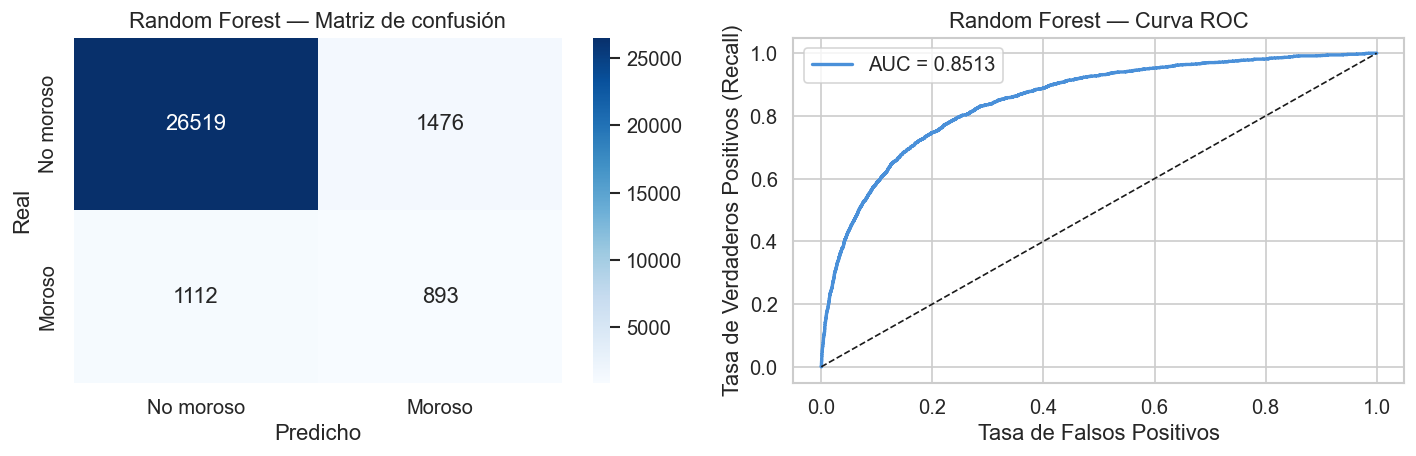

In [39]:
res_rf = evaluar_modelo('Random Forest', rf, X_test, y_test)
resultados.append(res_rf)

In [ ]:
# Importancia de variables (feature importance)
importancias = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importancias['Feature'], importancias['Importancia'],
        color='#4A90D9', edgecolor='none')
ax.set_title('Random Forest — Importancia de variables')
ax.set_xlabel('Importancia (mean decrease in impurity)')
plt.tight_layout()
plt.show()

---
## 5. XGBoost

Gradient boosting secuencial — cada árbol corrige los errores del anterior. Candidato principal por su rendimiento en datos tabulares con desbalance de clases.

El parámetro `scale_pos_weight` le indica al modelo cuánto más penalizar los errores en la clase minoritaria. Se calcula como el ratio entre clase mayoritaria y minoritaria del train set **antes** de SMOTE.

In [40]:
# scale_pos_weight = n_negativos / n_positivos (sobre el train original, sin SMOTE)
# Como ya aplicamos SMOTE, las clases están balanceadas → usamos 1
# Si no hubieras aplicado SMOTE: scale_pos_weight = 139974*0.8 / (10026*0.8) ≈ 13.9
scale_pos = 1

xgb = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos,
    use_label_encoder = False,
    eval_metric       = 'auc',
    random_state      = SEED,
    n_jobs            = -1
)
xgb.fit(
    X_train, y_train,
    eval_set          = [(X_test, y_test)],
    verbose           = False
)

joblib.dump(xgb, '../models/xgboost_final.pkl')
print('XGBoost entrenado y exportado.')

XGBoost entrenado y exportado.



  XGBoost
  AUC-ROC   : 0.8449
  Recall    : 0.2798  ← prioridad
  Precisión : 0.4610
  F1-Score  : 0.3482
  Accuracy  : 0.9300

              precision    recall  f1-score   support

   No moroso       0.95      0.98      0.96     27995
      Moroso       0.46      0.28      0.35      2005

    accuracy                           0.93     30000
   macro avg       0.71      0.63      0.66     30000
weighted avg       0.92      0.93      0.92     30000



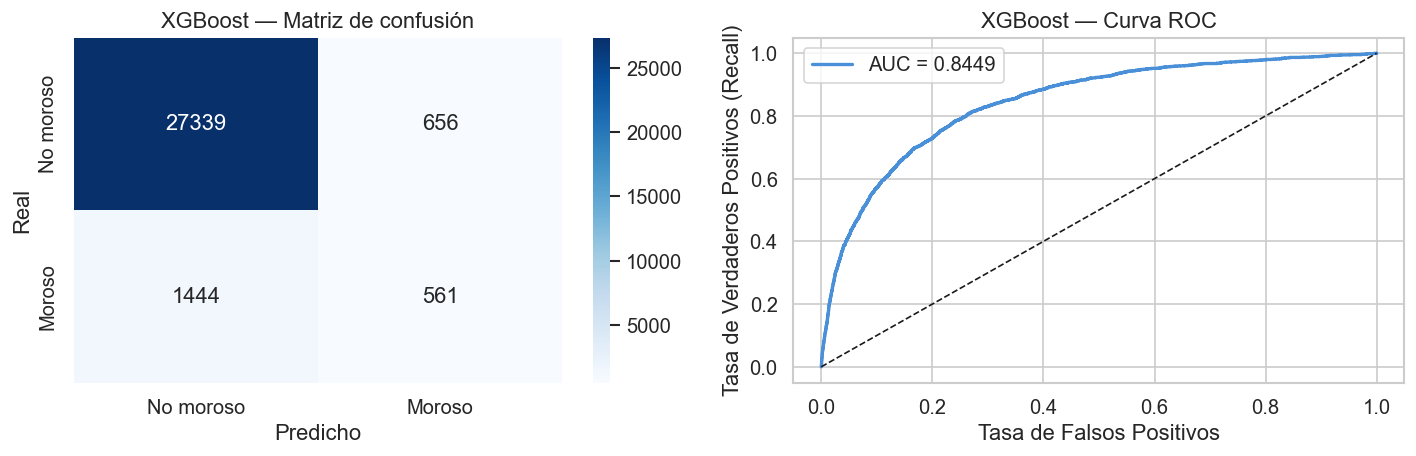

In [41]:
res_xgb = evaluar_modelo('XGBoost', xgb, X_test, y_test)
resultados.append(res_xgb)

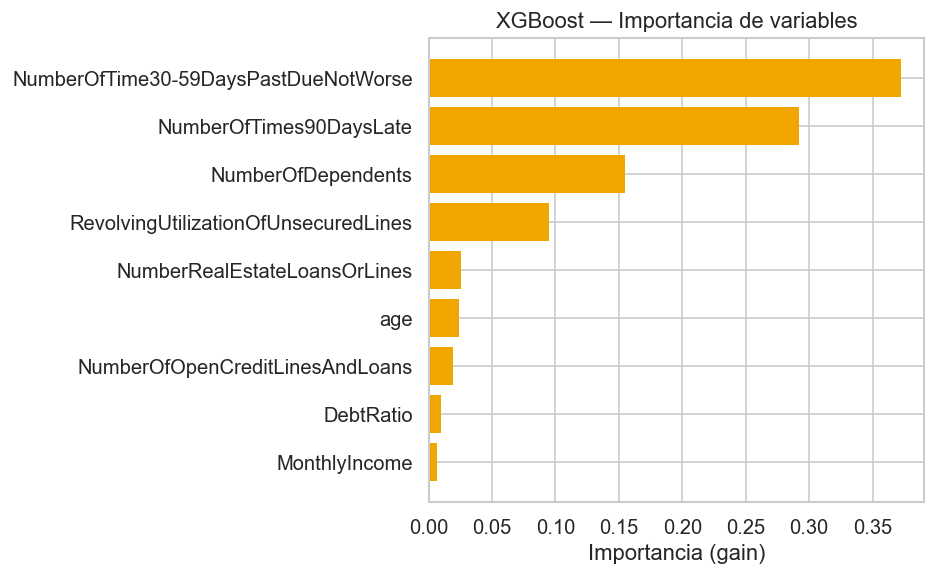

In [42]:
# Importancia de variables XGBoost
importancias_xgb = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Importancia': xgb.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importancias_xgb['Feature'], importancias_xgb['Importancia'],
        color='#F0A500', edgecolor='none')
ax.set_title('XGBoost — Importancia de variables')
ax.set_xlabel('Importancia (gain)')
plt.tight_layout()
plt.show()

---
## 6. Comparación de modelos

Comparamos los cuatro modelos con todas las métricas. **Criterio de selección:** mayor Recall sobre la clase morosa, con AUC-ROC > 0.80 como condición mínima.

In [43]:
df_resultados = pd.DataFrame(resultados).set_index('Modelo')

print('=== Comparación de métricas ===')
print(df_resultados.to_string())

# Exportar tabla
df_resultados.to_csv('../models/resultados_comparacion.csv')
print('\nTabla exportada en: models/resultados_comparacion.csv')

=== Comparación de métricas ===
                     AUC-ROC  Recall  Precisión  F1-Score  Accuracy
Modelo                                                             
Regresión Logística   0.8055  0.5781     0.2631    0.3616    0.8636
Árbol de Decisión     0.8300  0.3776     0.3904    0.3839    0.9190
Random Forest         0.8513  0.4454     0.3770    0.4083    0.9137
XGBoost               0.8449  0.2798     0.4610    0.3482    0.9300

Tabla exportada en: models/resultados_comparacion.csv


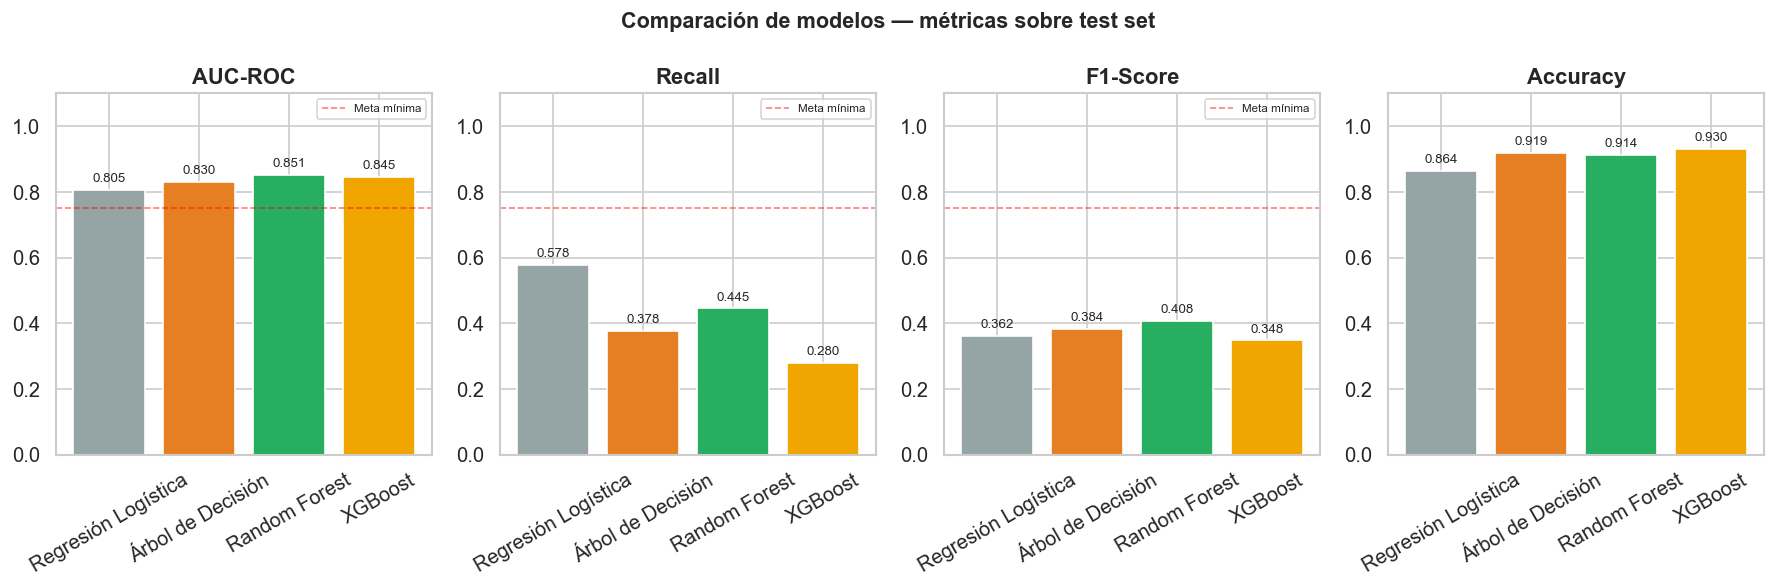

In [44]:
# Gráfico comparativo de métricas principales
metricas_plot = ['AUC-ROC', 'Recall', 'F1-Score', 'Accuracy']
colores_modelos = ['#95A5A6', '#E67E22', '#27AE60', '#F0A500']

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, metrica in enumerate(metricas_plot):
    valores = df_resultados[metrica]
    bars = axes[i].bar(valores.index, valores.values,
                       color=colores_modelos, edgecolor='white')
    axes[i].bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    axes[i].set_title(metrica, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].tick_params(axis='x', rotation=30)
    # Línea de umbral mínimo
    if metrica in ['AUC-ROC', 'Recall', 'F1-Score']:
        axes[i].axhline(0.75, color='red', lw=1, ls='--', alpha=0.5, label='Meta mínima')
        axes[i].legend(fontsize=7)

plt.suptitle('Comparación de modelos — métricas sobre test set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

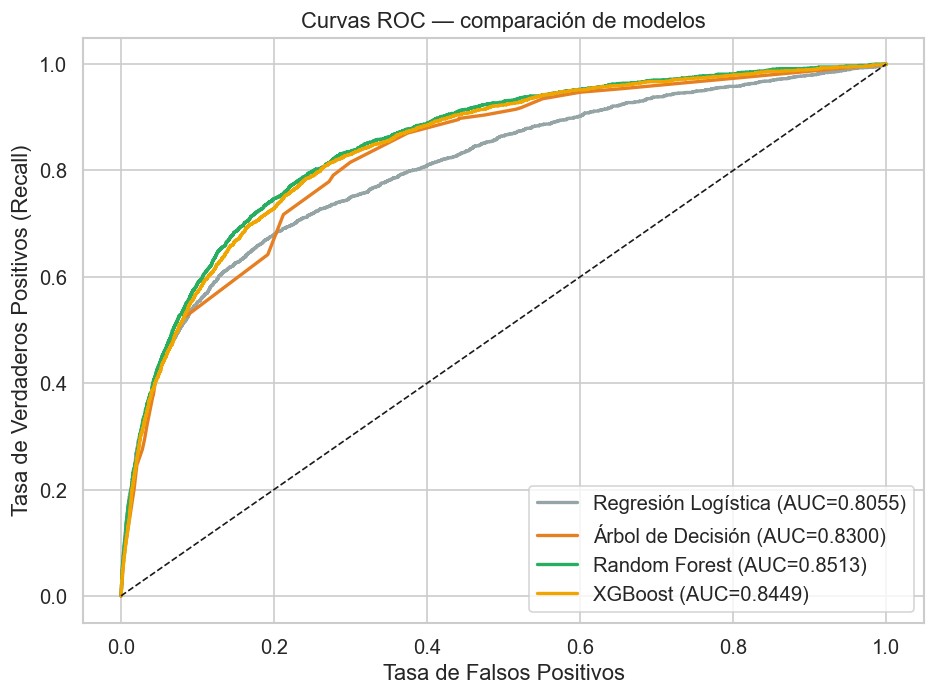

In [45]:
# Curvas ROC superpuestas — todos los modelos
modelos_dict = {
    'Regresión Logística': logreg,
    'Árbol de Decisión'  : dt,
    'Random Forest'      : rf,
    'XGBoost'            : xgb
}
colores_roc = ['#95A5A6', '#E67E22', '#27AE60', '#F0A500']

fig, ax = plt.subplots(figsize=(8, 6))
for (nombre, modelo), color in zip(modelos_dict.items(), colores_roc):
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Curvas ROC — comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 7. Ajuste de umbral de clasificación

Por defecto scikit-learn clasifica como moroso si `P(default) ≥ 0.5`. Pero en credit scoring nos interesa **maximizar Recall**: preferimos aprobar menos créditos que dejar pasar a un moroso.

Para cada modelo buscamos el umbral que maximiza el F1-Score, luego comparamos los cuatro con sus umbrales óptimos y dejamos que los números elijan al ganador.

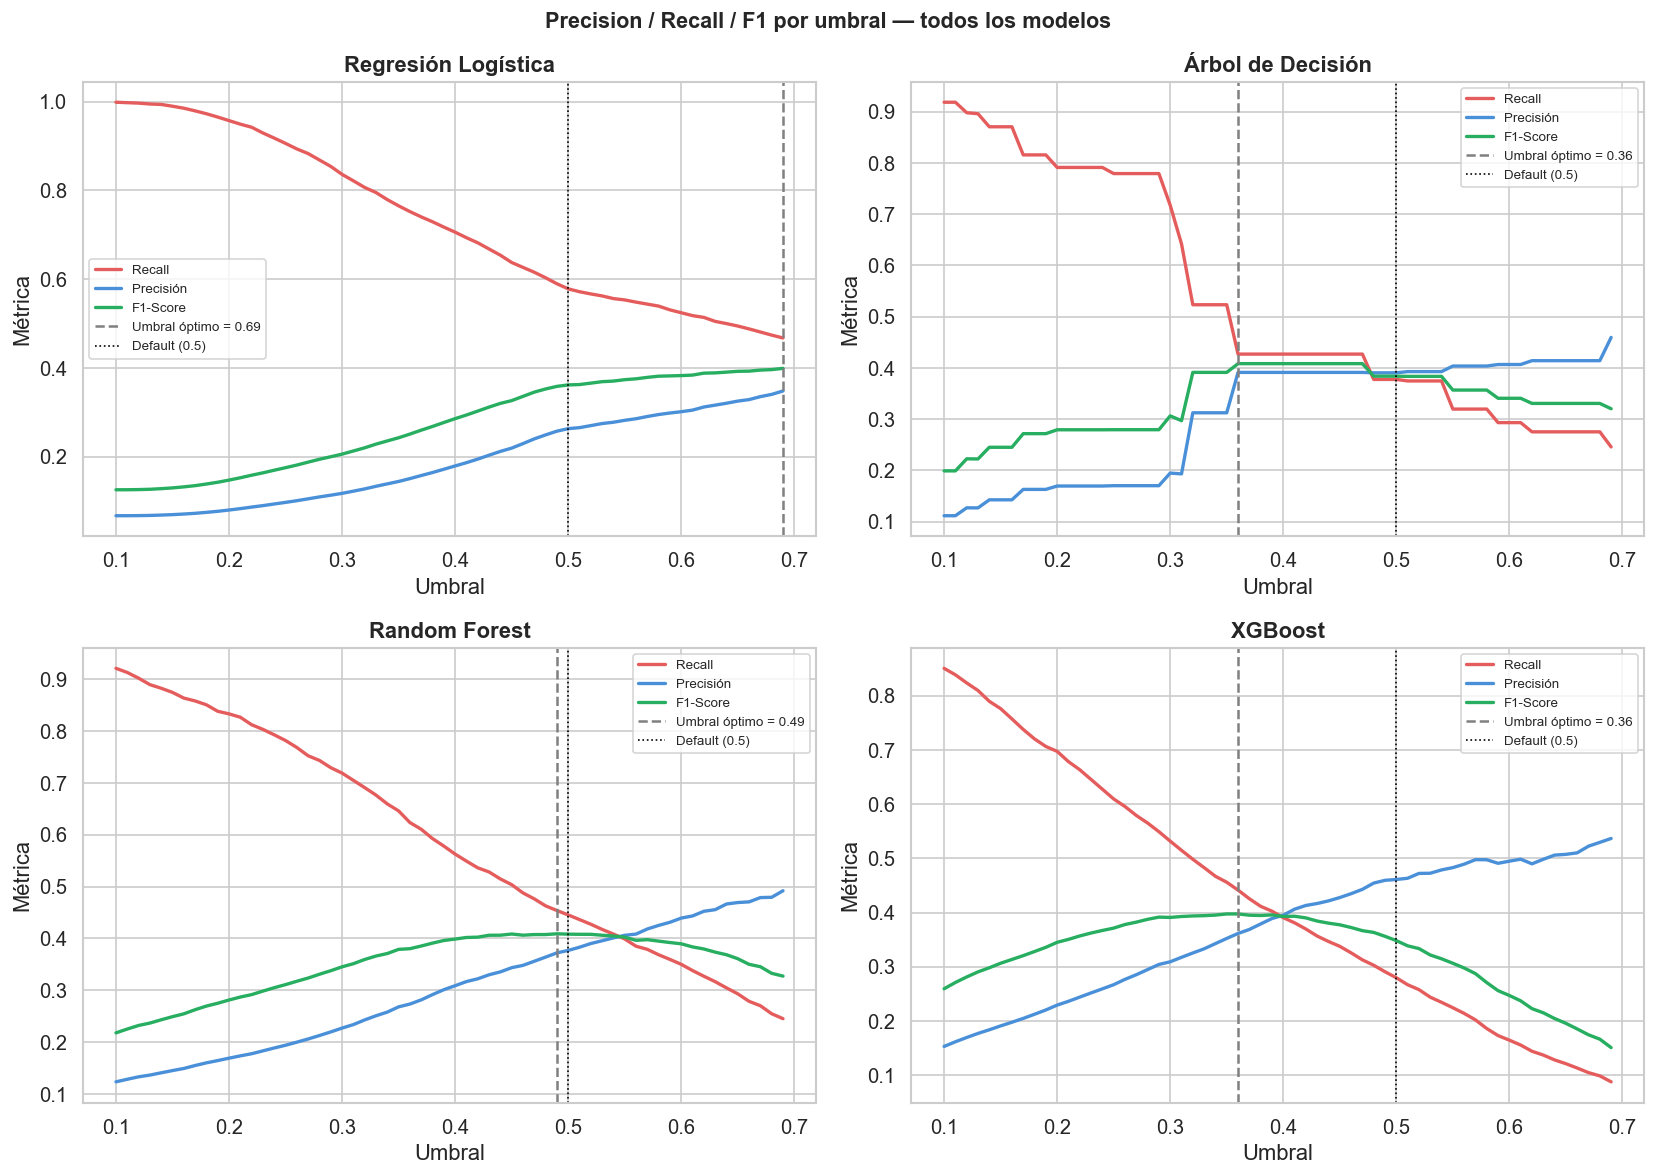

Umbrales óptimos encontrados:
  Regresión Logística: 0.69
  Árbol de Decisión: 0.36
  Random Forest: 0.49
  XGBoost: 0.36


In [46]:
modelos_dict = {
    'Regresión Logística': logreg,
    'Árbol de Decisión'  : dt,
    'Random Forest'      : rf,
    'XGBoost'            : xgb
}
colores_modelos_roc = ['#95A5A6', '#E67E22', '#27AE60', '#F0A500']
umbrales = np.arange(0.10, 0.70, 0.01)

# Gráfico de curvas Precision/Recall/F1 por umbral — uno por modelo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

umbrales_optimos = {}

for i, (nombre, modelo) in enumerate(modelos_dict.items()):
    y_prob = modelo.predict_proba(X_test)[:, 1]
    recalls_u, precisiones_u, f1s_u = [], [], []

    for u in umbrales:
        y_pred_u = (y_prob >= u).astype(int)
        recalls_u.append(recall_score(y_test, y_pred_u, zero_division=0))
        precisiones_u.append(precision_score(y_test, y_pred_u, zero_division=0))
        f1s_u.append(f1_score(y_test, y_pred_u, zero_division=0))

    umbral_opt = umbrales[np.argmax(f1s_u)]
    umbrales_optimos[nombre] = umbral_opt

    ax = axes[i]
    ax.plot(umbrales, recalls_u,     color='#E55C5C', lw=2, label='Recall')
    ax.plot(umbrales, precisiones_u, color='#4A90D9', lw=2, label='Precisión')
    ax.plot(umbrales, f1s_u,         color='#27AE60', lw=2, label='F1-Score')
    ax.axvline(umbral_opt, color='gray', lw=1.5, ls='--', label=f'Umbral óptimo = {umbral_opt:.2f}')
    ax.axvline(0.5, color='black', lw=1, ls=':', label='Default (0.5)')
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Umbral')
    ax.set_ylabel('Métrica')
    ax.legend(fontsize=8)

plt.suptitle('Precision / Recall / F1 por umbral — todos los modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Umbrales óptimos encontrados:')
for nombre, u in umbrales_optimos.items():
    print(f'  {nombre}: {u:.2f}')


  Regresión Logística (umbral=0.69)
  AUC-ROC   : 0.8055
  Recall    : 0.4673  ← prioridad
  Precisión : 0.3479
  F1-Score  : 0.3989
  Accuracy  : 0.9059

              precision    recall  f1-score   support

   No moroso       0.96      0.94      0.95     27995
      Moroso       0.35      0.47      0.40      2005

    accuracy                           0.91     30000
   macro avg       0.65      0.70      0.67     30000
weighted avg       0.92      0.91      0.91     30000



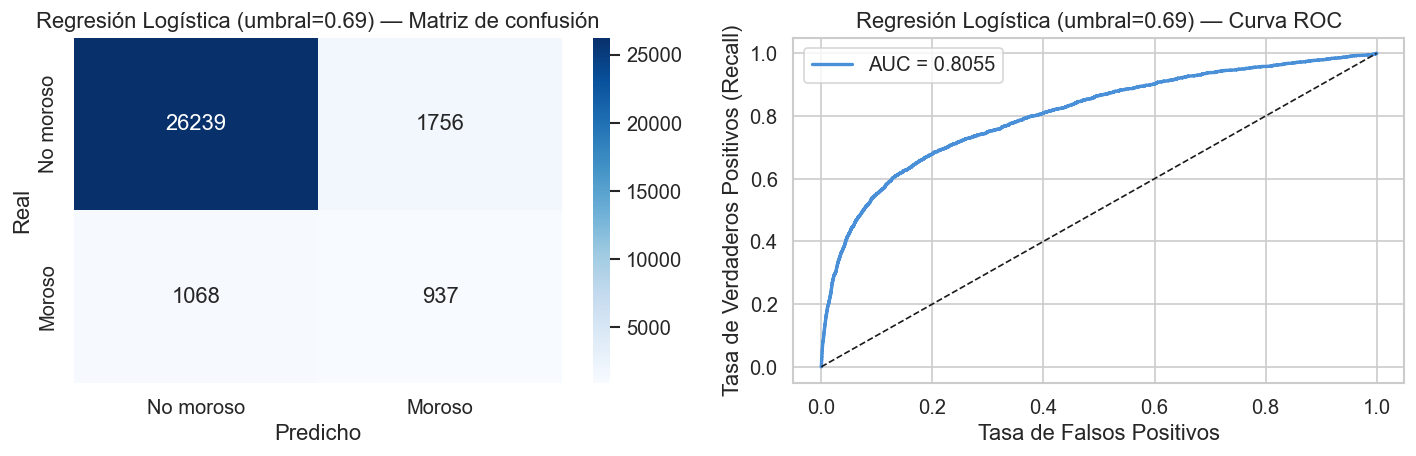


  Árbol de Decisión (umbral=0.36)
  AUC-ROC   : 0.8300
  Recall    : 0.4269  ← prioridad
  Precisión : 0.3912
  F1-Score  : 0.4083
  Accuracy  : 0.9173

              precision    recall  f1-score   support

   No moroso       0.96      0.95      0.96     27995
      Moroso       0.39      0.43      0.41      2005

    accuracy                           0.92     30000
   macro avg       0.67      0.69      0.68     30000
weighted avg       0.92      0.92      0.92     30000



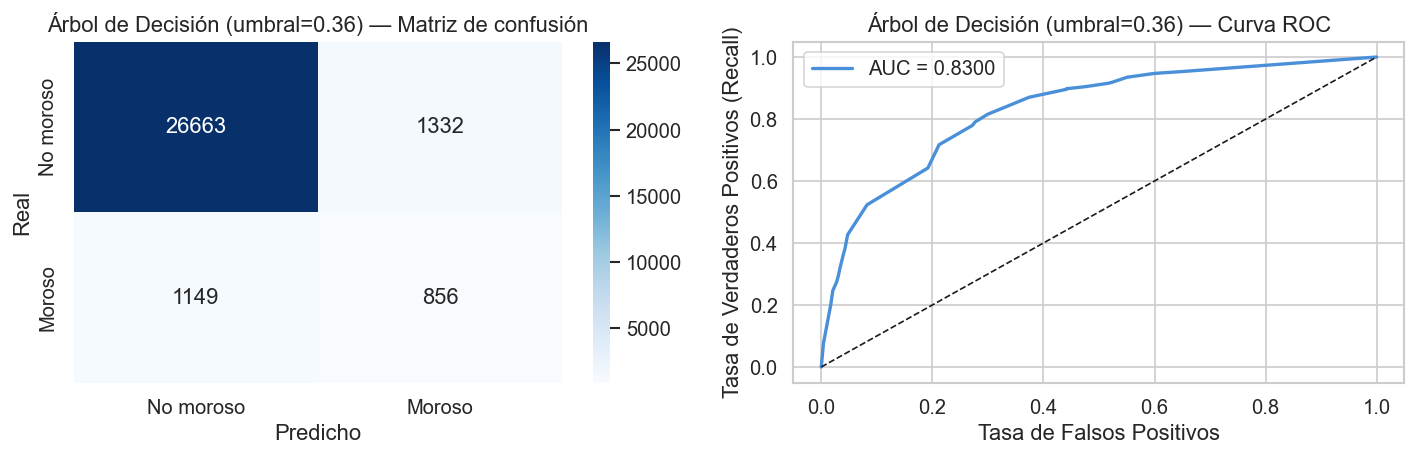


  Random Forest (umbral=0.49)
  AUC-ROC   : 0.8513
  Recall    : 0.4539  ← prioridad
  Precisión : 0.3722
  F1-Score  : 0.4090
  Accuracy  : 0.9123

              precision    recall  f1-score   support

   No moroso       0.96      0.95      0.95     27995
      Moroso       0.37      0.45      0.41      2005

    accuracy                           0.91     30000
   macro avg       0.67      0.70      0.68     30000
weighted avg       0.92      0.91      0.92     30000



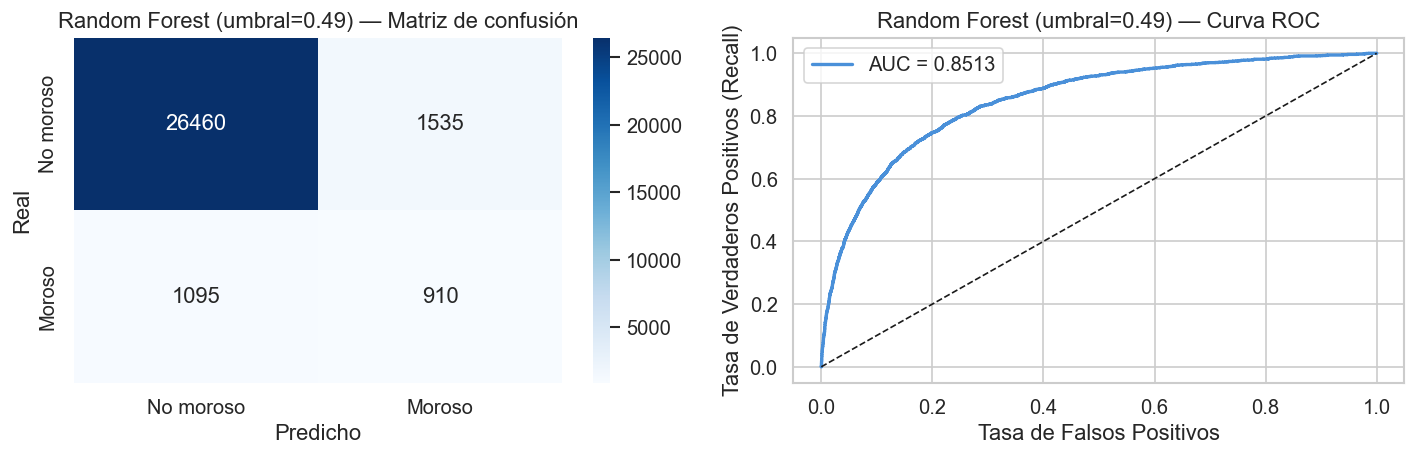


  XGBoost (umbral=0.36)
  AUC-ROC   : 0.8449
  Recall    : 0.4414  ← prioridad
  Precisión : 0.3614
  F1-Score  : 0.3974
  Accuracy  : 0.9105

              precision    recall  f1-score   support

   No moroso       0.96      0.94      0.95     27995
      Moroso       0.36      0.44      0.40      2005

    accuracy                           0.91     30000
   macro avg       0.66      0.69      0.67     30000
weighted avg       0.92      0.91      0.91     30000



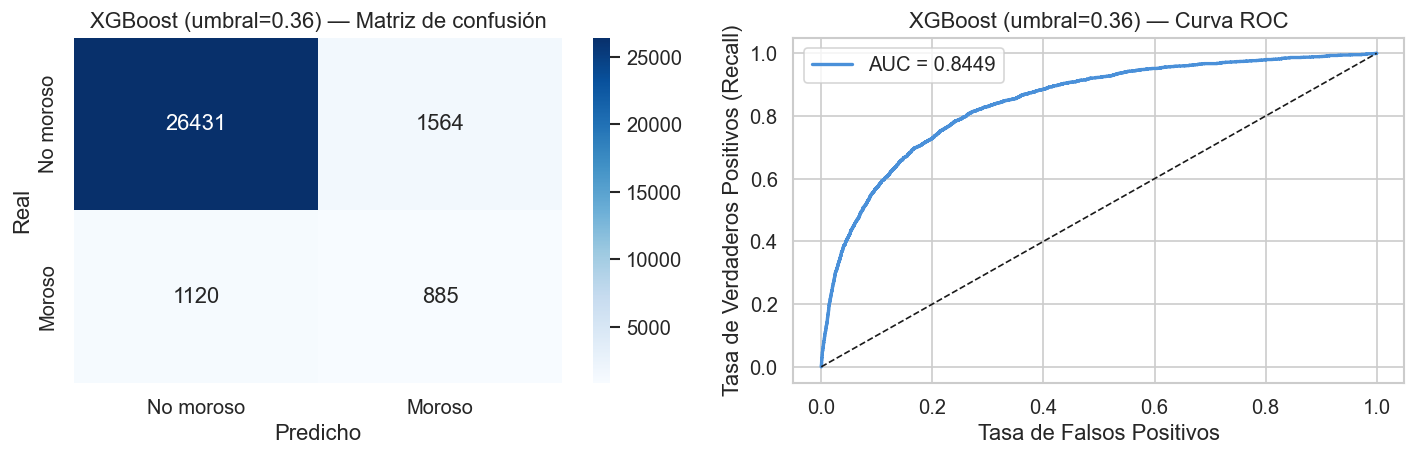


=== Comparación final con umbrales óptimos ===
                                   AUC-ROC  Recall  Precisión  F1-Score  Accuracy
Modelo                                                                           
Regresión Logística (umbral=0.69)   0.8055  0.4673     0.3479    0.3989    0.9059
Árbol de Decisión (umbral=0.36)     0.8300  0.4269     0.3912    0.4083    0.9173
Random Forest (umbral=0.49)         0.8513  0.4539     0.3722    0.4090    0.9123
XGBoost (umbral=0.36)               0.8449  0.4414     0.3614    0.3974    0.9105


In [47]:
# Evaluación final de todos los modelos con su umbral óptimo
resultados_opt = []

for nombre, modelo in modelos_dict.items():
    umbral_opt = umbrales_optimos[nombre]
    res = evaluar_modelo(
        f'{nombre} (umbral={umbral_opt:.2f})',
        modelo, X_test, y_test,
        umbral=umbral_opt
    )
    res['modelo_base'] = nombre
    res['umbral']      = umbral_opt
    resultados_opt.append(res)

df_opt = pd.DataFrame(resultados_opt).set_index('Modelo')
print('\n=== Comparación final con umbrales óptimos ===')
print(df_opt[['AUC-ROC', 'Recall', 'Precisión', 'F1-Score', 'Accuracy']].to_string())

---
## 8. Selección y exportación del modelo ganador

**Criterio de selección automática:**
1. AUC-ROC ≥ 0.80 (condición mínima)
2. Entre los que pasan el filtro, el mayor AUC-ROC

El código selecciona al ganador sin intervención manual — lo que digan los números.

In [48]:
import json

# Filtrar modelos que superan AUC mínimo y seleccionar por mayor AUC-ROC
df_candidatos = df_opt[df_opt['AUC-ROC'] >= 0.80].copy()

if df_candidatos.empty:
    raise ValueError('Ningún modelo supera el AUC mínimo de 0.80 — revisar pipeline.')

# Ganador: mayor AUC-ROC entre los candidatos
ganador_idx  = df_candidatos['AUC-ROC'].idxmax()
ganador_info = df_opt.loc[ganador_idx]
nombre_ganador = ganador_info['modelo_base']
umbral_ganador = ganador_info['umbral']

# Mapeo nombre → objeto modelo y nombre de archivo
archivos_modelo = {
    'Regresión Logística': ('logreg',        logreg),
    'Árbol de Decisión'  : ('decision_tree', dt),
    'Random Forest'      : ('random_forest', rf),
    'XGBoost'            : ('xgboost',       xgb)
}
archivo_base, modelo_ganador = archivos_modelo[nombre_ganador]

print(f'╔══════════════════════════════════════════╗')
print(f'  MODELO GANADOR: {nombre_ganador}')
print(f'  AUC-ROC : {ganador_info["AUC-ROC"]:.4f}')
print(f'  Recall  : {ganador_info["Recall"]:.4f}')
print(f'  F1-Score: {ganador_info["F1-Score"]:.4f}')
print(f'  Umbral  : {umbral_ganador:.2f}')
print(f'╚══════════════════════════════════════════╝')

# Exportar modelo ganador
ruta_ganador = f'../models/{archivo_base}_ganador.pkl'
joblib.dump(modelo_ganador, ruta_ganador)

# Exportar metadata para Streamlit
metadata = {
    'modelo'        : nombre_ganador,
    'archivo'       : f'{archivo_base}_ganador.pkl',
    'umbral_optimo' : round(float(umbral_ganador), 2),
    'auc_roc'       : round(float(ganador_info['AUC-ROC']), 4),
    'recall'        : round(float(ganador_info['Recall']), 4),
    'f1_score'      : round(float(ganador_info['F1-Score']), 4),
    'features'      : list(X_train.columns),
    'target'        : TARGET,
    'seed'          : SEED
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

df_opt.to_csv('../models/resultados_comparacion_final.csv')

print()
print('Archivos exportados en models/:')
print('  ✓ logreg.pkl')
print('  ✓ decision_tree.pkl')
print('  ✓ random_forest.pkl')
print('  ✓ xgboost.pkl')
print(f'  ✓ {archivo_base}_ganador.pkl           ← modelo ganador')
print('  ✓ model_metadata.json                  ← umbral + features para Streamlit')
print('  ✓ resultados_comparacion_final.csv')
print()
print('Siguiente paso: Notebook 04 — Evaluación y SHAP')

╔══════════════════════════════════════════╗
  MODELO GANADOR: Random Forest
  AUC-ROC : 0.8513
  Recall  : 0.4539
  F1-Score: 0.4090
  Umbral  : 0.49
╚══════════════════════════════════════════╝

Archivos exportados en models/:
  ✓ logreg.pkl
  ✓ decision_tree.pkl
  ✓ random_forest.pkl
  ✓ xgboost.pkl
  ✓ random_forest_ganador.pkl           ← modelo ganador
  ✓ model_metadata.json                  ← umbral + features para Streamlit
  ✓ resultados_comparacion_final.csv

Siguiente paso: Notebook 04 — Evaluación y SHAP
